# **CS 559-WS1: Machine Learning: Fundamentals and Applications**
# **Homework 5**

**Name: Ankit Dhandharia**

**CWID: 20033031**

In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.decomposition import PCA as SklearnPCA

## **Part 1: Clustering Analysis**

### **a. Load the provided data - autompg.csv. The data contains seven columns. This data set can be used for both classification and regression problems.**

In [33]:
data = pd.read_csv("autompg.csv")
data.head()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model-year
0,18.0,8,307.0,130.0,3504,12.0,70
1,15.0,8,350.0,165.0,3693,11.5,70
2,18.0,8,318.0,150.0,3436,11.0,70
3,16.0,8,304.0,150.0,3433,12.0,70
4,17.0,8,302.0,140.0,3449,10.5,70


In [34]:
data.shape

(398, 7)

### **b. Transform mpg into an ordinal categorical feature with three values [good (2), average (1), bad (0)] by calculating the quantiles using numpy.quantile. For other continuous columns, convert to four-valued ordinal categorical features as (4) - high, (3) - good, (2) - okay, (1) - poor.**

In [35]:
df = data.copy()

# MPG transformation
mpg_q = np.quantile(df['mpg'], [0.33, 0.67])
df['mpg_cat'] = pd.cut(df['mpg'],
                bins=[0, mpg_q[0],
                mpg_q[1], np.inf],
                labels=[0, 1, 2],
                include_lowest=True)

# Transform continuous features
continuous_cols = ['cylinders', 'displacement', 'horsepower', 'weight', 'acceleration']
for col in continuous_cols:
    qs = np.quantile(df[col].dropna(), [0.25, 0.5, 0.75])
    bins = [-np.inf] + sorted(set(qs.tolist())) + [np.inf]
    labels = list(range(1, len(bins)))
    df[f'{col}_cat'] = pd.cut(df[col], bins=bins, labels=labels, include_lowest=True)

# Final categorical dataset
X_categorical = df[['mpg_cat'] + [f'{col}_cat' for col in continuous_cols]].dropna().astype(int)
X_np = X_categorical.to_numpy()
X_categorical.head()

,mpg_cat,cylinders_cat,displacement_cat,horsepower_cat,weight_cat,acceleration_cat
0,0,2,4,4,3,1
1,0,2,4,4,4,1
2,0,2,4,4,3,1
3,0,2,4,4,3,1
4,0,2,4,4,3,1


### **c. Implement a myKmeans(X, k, max iter) algorithm as a function (not a class) using only NumPy. The parameter X is the data, k is the number of clusters, and max iter is the maximum number of iterations. The function returns the final cluster labels, the final centroids of the clusters, and the final inertia, which is defined as the sum of the squared distance of each data point to its cluster centroid.**

In [36]:
def myKmeans(X, k, max_iter):
    n_samples, n_features = X.shape
    centroids = X[np.random.choice(n_samples, k, replace=False)].astype(float)
    labels = np.zeros(n_samples)
    for _ in range(max_iter):
        new_labels = np.array([
            np.argmin([np.linalg.norm(x - c) for c in centroids]) for x in X
        ])
        if np.array_equal(labels, new_labels):
            break
        labels = new_labels
        for j in range(k):
            points = X[labels == j]
            if len(points) > 0:
                centroids[j] = np.mean(points, axis=0)
    inertia = np.sum([
        np.linalg.norm(X[i] - centroids[int(labels[i])])**2 for i in range(n_samples)
    ])
    return labels, centroids, inertia

### **d. Determine the appropriate k value of the new data set using myKmeans. Show that the inertia converges as k increases.**

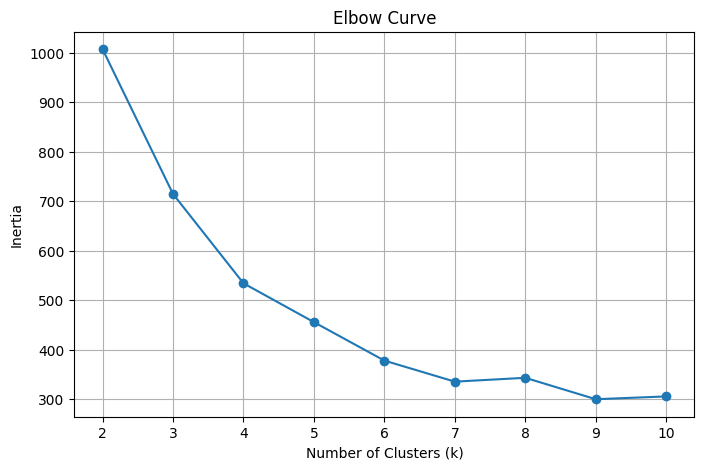

In [37]:
inertias = []
k_range = range(2, 11)
for k in k_range:
    _, _, inertia = myKmeans(X_np, k, max_iter=100)
    inertias.append(inertia)
plt.figure(figsize=(8, 5))
plt.plot(k_range, inertias, 'o-')
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Inertia")
plt.title("Elbow Curve")
plt.grid(True)
plt.show()

### **e.Using the results of myKmeans with the best k value from (d), build a linear classification model using Scikit-learn that predicts the cluster label. Split the data into training and test sets by 8 to 2, and report the accuracy for both train and test.**